# 🫀🫁 Symile-MIMIC — Multimodal Late Fusion v4 (FINAL)

**Objetivo:** AUC ≥ 0.80 en clasificación multietiqueta de 4 patologías cardiorrespiratorias.

### Mejoras respecto a v3 (que alcanzó AUC ~0.72)

| # | Mejora | Impacto esperado en AUC |
|---|---|---|
| 1 | **Multi-Window Attention** en torre CXR (ViT-style local patches) | +3–5% |
| 2 | **EfficientNet-B3** como backbone CXR (mejor ratio eficiencia/precisión que ResNet50) | +2–4% |
| 3 | **mmap_mode='r'** en todos los np.load (resuelve RAM >10 GB) | 0% AUC, evita crash |
| 4 | **Focal Loss** reemplaza BCE+pos_weight (mejor para desequilibrio severo) | +2–4% |
| 5 | **Cosine Warmup + Annealing** (warm-up 3 epochs → cosine decay) | +1–2% |
| 6 | **Cross-Modal Attention** en fusión (labs y ECG atienden sobre CXR) | +1–3% |
| 7 | **Checkpoint anti-desconexión**: guarda cada epoch + mejor AUC | seguridad |
| 8 | **GradCAM** reescrito con API correcta de pytorch-grad-cam ≥0.2.x | fix bugs |
| 9 | **Early stopping** con patience=10 y monitoreo por AUC (no loss) | eficiencia |

---
> Ejecuta las celdas **de arriba hacia abajo** sin saltar pasos.

## CELDA 1 — Instalación de dependencias

In [2]:
import subprocess, sys

packages = [
    'grad-cam>=1.5.0',   # API estable; versiones <0.3 tienen firma diferente
    'timm>=0.9.0',       # EfficientNet-B3 preentrenado
    'seaborn',
    'scikit-learn',
]
for pkg in packages:
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg],
                       capture_output=True, text=True)
    icon = '✅' if r.returncode == 0 else '❌'
    print(f'{icon} {pkg}')

print('\nVerificando versiones instaladas...')
import torch, torchvision, numpy, pandas, sklearn, timm
import pytorch_grad_cam
for lib in [torch, torchvision, numpy, pandas, sklearn, timm]:
    print(f'  {lib.__name__:25s}: {lib.__version__}')
print(f'  pytorch_grad_cam         : {pytorch_grad_cam.__version__ if hasattr(pytorch_grad_cam, '__version__') else 'Version not available via __version__ attribute'}')

✅ grad-cam>=1.5.0
✅ timm>=0.9.0
✅ seaborn
✅ scikit-learn

Verificando versiones instaladas...
  torch                    : 2.10.0+cu128
  torchvision              : 0.25.0+cu128
  numpy                    : 2.0.2
  pandas                   : 2.2.2
  sklearn                  : 1.6.1
  timm                     : 1.0.26
  pytorch_grad_cam         : Version not available via __version__ attribute


## CELDA 2 — Imports y configuración global

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Todos los imports del proyecto en un solo lugar
# ─────────────────────────────────────────────────────────────────────────────
import os, time, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import timm                                  # EfficientNet-B3

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_fscore_support,
    accuracy_score, multilabel_confusion_matrix,
    jaccard_score
)

# pytorch-grad-cam — API v1.5+
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True   # acelera conv layers en GPU fija

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('⚠️  Sin GPU — cambia: Entorno de ejecución → T4 GPU')

✅ Device: cuda
   GPU : Tesla T4
   VRAM: 15.6 GB


## CELDA 3 — Rutas y variables globales

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Montar Google Drive y definir todas las rutas
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/Proyecto_IA'
DATASET_DIR = os.path.join(
    PROJECT_DIR,
    'symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-'
    'electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0'
)
DATA_NPY = os.path.join(DATASET_DIR, 'data_npy')

PATHS = {
    split: {
        'cxr'    : os.path.join(DATA_NPY, split, f'cxr_{split}.npy'),
        'ecg'    : os.path.join(DATA_NPY, split, f'ecg_{split}.npy'),
        'labs'   : os.path.join(DATA_NPY, split, f'labs_percentiles_{split}.npy'),
        'hadm_id': os.path.join(DATA_NPY, split, f'hadm_id_{split}.npy'),
        'csv'    : os.path.join(DATASET_DIR, f'{split}.csv'),
    }
    for split in ['train', 'val', 'test']
}

# ── Etiquetas objetivo ───────────────────────────────────────────────────────
TARGET_LABELS = ['Atelectasis', 'Cardiomegaly', 'Edema', 'Pleural Effusion']

# Nombres de las 50 columnas _percentile (orden exacto del CSV)
PERCENTILE_IDS = [
    '51221','51265','50912','50971','51222','51301','51249','51279',
    '51250','51248','51277','51006','50983','50902','50882','50868',
    '50931','50960','50893','50970','51237','51274','51275','51146',
    '51256','51254','51200','51244','52172','50934','51678','50947',
    '50861','50878','50813','50863','50885','50820','50862','50802',
    '50821','50804','50818','52075','52073','52074','52069','51133',
    '50910','52135'
]
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

# ── Hiperparámetros ──────────────────────────────────────────────────────────
BATCH_SIZE       = 16      # bajar a 8 si hay OOM
NUM_WORKERS      = 2
EMBED_CXR        = 256
EMBED_ECG        = 128
EMBED_LABS       = 64
NUM_CLASSES      = 4
LEARNING_RATE    = 3e-4
NUM_EPOCHS       = 35
WARMUP_EPOCHS    = 3
EARLY_STOP_PAT   = 10     # patience para early stopping
THRESHOLD        = 0.5

# pos_weight calculado del CSV real de train (n_neg / n_pos por clase)
POS_WEIGHT = torch.tensor([2.4880, 1.9886, 3.8379, 1.7640])

# ── Checkpoints ──────────────────────────────────────────────────────────────
CKPT_BEST = os.path.join(PROJECT_DIR, 'best_v4.pt')
CKPT_LAST = os.path.join(PROJECT_DIR, 'last_v4.pt')

# ── Verificar archivos ────────────────────────────────────────────────────────
print('\n🔍 Verificando archivos...')
all_ok = True
for split, d in PATHS.items():
    for key, path in d.items():
        ok = os.path.exists(path)
        if not ok: all_ok = False
        print(f'  {"✅" if ok else "❌"} [{split}][{key}]: {os.path.basename(path)}')
print(f'\n{"✅ Todo encontrado." if all_ok else "❌ Faltan archivos — revisar rutas."}')

Mounted at /content/drive

🔍 Verificando archivos...
  ✅ [train][cxr]: cxr_train.npy
  ✅ [train][ecg]: ecg_train.npy
  ✅ [train][labs]: labs_percentiles_train.npy
  ✅ [train][hadm_id]: hadm_id_train.npy
  ✅ [train][csv]: train.csv
  ✅ [val][cxr]: cxr_val.npy
  ✅ [val][ecg]: ecg_val.npy
  ✅ [val][labs]: labs_percentiles_val.npy
  ✅ [val][hadm_id]: hadm_id_val.npy
  ✅ [val][csv]: val.csv
  ✅ [test][cxr]: cxr_test.npy
  ✅ [test][ecg]: ecg_test.npy
  ✅ [test][labs]: labs_percentiles_test.npy
  ✅ [test][hadm_id]: hadm_id_test.npy
  ✅ [test][csv]: test.csv

✅ Todo encontrado.


## CELDA 4 — Dataset con mmap_mode y alineación robusta

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# SymileMultimodalDataset v4
#
# CAMBIO CLAVE: mmap_mode='r' en np.load para CXR y ECG.
# Con mmap, NumPy NO carga el array completo en RAM al instanciar el Dataset.
# En cambio, mapea el archivo en disco y carga solo los bloques que
# __getitem__ solicita. Esto reduce el pico de RAM de ~15 GB → ~2-3 GB.
# Labs y hadm_ids son pequeños (<100 MB) y se cargan completos en RAM.
# ─────────────────────────────────────────────────────────────────────────────

class SymileMultimodalDataset(Dataset):
    def __init__(self, split, paths, target_labels):
        super().__init__()
        self.split         = split
        self.target_labels = target_labels

        print(f'\n[{split.upper()}] Cargando tensores...')

        # CXR y ECG: mmap_mode='r' — lectura bajo demanda, no consume RAM masiva
        try:
            self.cxr  = np.load(paths['cxr'], mmap_mode='r', allow_pickle=False)
            self.ecg  = np.load(paths['ecg'], mmap_mode='r', allow_pickle=False)
        except ValueError:
            self.cxr  = np.load(paths['cxr'], mmap_mode='r', allow_pickle=True)
            self.ecg  = np.load(paths['ecg'], mmap_mode='r', allow_pickle=True)

        # Labs y hadm_ids son pequeños: cargar completos en RAM para velocidad
        try:
            self.labs     = np.load(paths['labs'],    allow_pickle=False).astype(np.float32)
            self.hadm_ids = np.load(paths['hadm_id'], allow_pickle=False)
        except ValueError:
            self.labs     = np.load(paths['labs'],    allow_pickle=True).astype(np.float32)
            self.hadm_ids = np.load(paths['hadm_id'], allow_pickle=True)

        print(f'  cxr      : {self.cxr.shape}  [mmap]')
        print(f'  ecg      : {self.ecg.shape}  [mmap]')
        print(f'  labs     : {self.labs.shape}')
        print(f'  hadm_ids : {self.hadm_ids.shape}  dtype={self.hadm_ids.dtype}')
        assert self.labs.shape[1] == 50, f'Se esperaban 50 cols en labs, hay {self.labs.shape[1]}'

        # ── Imputar NaN en labs con 0.5 (mediana de [0,1]) ───────────────────
        nan_mask = np.isnan(self.labs)
        self.labs[nan_mask] = 0.5

        # ── Procesar CSV ─────────────────────────────────────────────────────
        print(f'[{split.upper()}] Procesando CSV...')
        df = pd.read_csv(paths['csv'])
        df = df.drop_duplicates(subset=['hadm_id'], keep='first').reset_index(drop=True)

        # Binarizar: solo 1.0 → positivo; 0.0, -1.0 (incierto), NaN → 0
        for col in self.target_labels:
            if col in df.columns:
                df[col] = (df[col] == 1.0).astype(np.float32)
            else:
                df[col] = 0.0

        # Pacientes sin hallazgos: todas las etiquetas → 0
        if 'No Finding' in df.columns:
            mask_nf = (df['No Finding'] == 1.0)
            df.loc[mask_nf, self.target_labels] = 0.0
            print(f'  No Finding → 0 para {mask_nf.sum()} pacientes')

        # ── Alinear tensor con CSV por hadm_id ───────────────────────────────
        df_idx = df.set_index('hadm_id')
        valid_idx, labels_list = [], []

        for ti, h in enumerate(self.hadm_ids):
            key = int(h)
            if key in df_idx.index:
                labels_list.append(df_idx.loc[key, self.target_labels].values.astype(np.float32))
                valid_idx.append(ti)

        if not valid_idx:
            raise ValueError(f'[{split}] Ningún hadm_id coincidió. Verifica que el CSV es del mismo split.')

        self.valid_indices = np.array(valid_idx)
        self.labels        = np.array(labels_list, dtype=np.float32)

        n_ok = len(valid_idx)
        print(f'  Muestras válidas: {n_ok} / {len(self.hadm_ids)}')
        print(f'  Prevalencia:')
        for i, lbl in enumerate(self.target_labels):
            pos = int(self.labels[:, i].sum())
            print(f'    {lbl:20s}: {pos:5d} ({100*pos/n_ok:.1f}%)')

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        ti = self.valid_indices[idx]

        # mmap: .copy() es obligatorio para obtener un array C-contiguo
        # que torch.tensor() pueda convertir sin error
        cxr_np  = np.array(self.cxr[ti],  dtype=np.float32)   # copia del mmap
        ecg_np  = np.array(self.ecg[ti],  dtype=np.float32)
        labs_np = self.labs[ti]   # ya en RAM, sin mmap

        cxr_t  = torch.from_numpy(cxr_np)
        ecg_t  = torch.from_numpy(ecg_np)
        labs_t = torch.from_numpy(labs_np)
        label  = torch.tensor(self.labels[idx], dtype=torch.float32)

        # Normalizar CXR a [0,1] si viene en [0,255]
        if cxr_t.max() > 1.0:
            cxr_t = cxr_t / 255.0

        return {'cxr': cxr_t, 'ecg': ecg_t, 'labs': labs_t, 'label': label}

print('✅ SymileMultimodalDataset definido.')

✅ SymileMultimodalDataset definido.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Instanciar datasets y sanity check
# ─────────────────────────────────────────────────────────────────────────────
train_dataset = SymileMultimodalDataset('train', PATHS['train'], TARGET_LABELS)
val_dataset   = SymileMultimodalDataset('val',   PATHS['val'],   TARGET_LABELS)
test_dataset  = SymileMultimodalDataset('test',  PATHS['test'],  TARGET_LABELS)

print('\n🔬 Sanity check — muestra 0 del train:')
s = train_dataset[0]
for k, v in s.items():
    print(f'  {k:8s} → {tuple(v.shape)}  min={v.min():.3f}  max={v.max():.3f}  NaN={torch.isnan(v).sum().item()}')

print(f'\n📊 Splits: train={len(train_dataset):,} | val={len(val_dataset):,} | test={len(test_dataset):,}')


[TRAIN] Cargando tensores...
  cxr      : (10000, 3, 320, 320)  [mmap]
  ecg      : (10000, 1, 5000, 12)  [mmap]
  labs     : (10000, 50)
  hadm_ids : (10000,)  dtype=int64
[TRAIN] Procesando CSV...
  No Finding → 0 para 1368 pacientes
  Muestras válidas: 10000 / 10000
  Prevalencia:
    Atelectasis         :  2867 (28.7%)
    Cardiomegaly        :  3346 (33.5%)
    Edema               :  2067 (20.7%)
    Pleural Effusion    :  3618 (36.2%)

[VAL] Cargando tensores...
  cxr      : (750, 3, 320, 320)  [mmap]
  ecg      : (750, 1, 5000, 12)  [mmap]
  labs     : (750, 50)
  hadm_ids : (750,)  dtype=int64
[VAL] Procesando CSV...
  No Finding → 0 para 113 pacientes
  Muestras válidas: 750 / 750
  Prevalencia:
    Atelectasis         :   225 (30.0%)
    Cardiomegaly        :   268 (35.7%)
    Edema               :   148 (19.7%)
    Pleural Effusion    :   253 (33.7%)

[TEST] Cargando tensores...
  cxr      : (4640, 3, 320, 320)  [mmap]
  ecg      : (4640, 1, 5000, 12)  [mmap]
  labs     : (

## CELDA 5 — Arquitectura v4 con Multi-Window Attention y Cross-Modal Fusion

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# TORRE CXR — EfficientNet-B3 + Multi-Window Self-Attention
#
# Por qué EfficientNet-B3 en lugar de ResNet50:
#   - Mismo costo computacional pero ~5% más preciso en clasificación médica
#   - Escala balanceada (profundidad + anchura + resolución) diseñada para imágenes
#
# Multi-Window Attention:
#   El feature map de EfficientNet (B, C, H, W) se divide en ventanas locales
#   de tamaño window_size × window_size. Dentro de cada ventana se aplica
#   self-attention. Esto permite al modelo aprender relaciones espaciales
#   entre regiones anatómicas cercanas (ej: borde cardiaco vs. parénquima pulmonar)
#   sin el coste O(N²) de un ViT global.
# ─────────────────────────────────────────────────────────────────────────────

class WindowAttention(nn.Module):
    """
    Self-attention dentro de ventanas locales del feature map.

    Flujo:
      (B, C, H, W) → dividir en ventanas (w×w)
      → MultiheadAttention dentro de cada ventana
      → reconstruir (B, C, H, W)

    Coste: O(B × (H/w × W/w) × (w²)²) vs O(B × (HW)²) en ViT global.
    Con w=4 sobre un mapa 10×10: 25× más barato que atención global.
    """
    def __init__(self, dim, num_heads=4, window_size=4, dropout=0.1):
        super().__init__()
        self.window_size = window_size
        self.attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        # x: (B, C, H, W)
        B, C, H, W = x.shape
        w = self.window_size

        # Padding para que H y W sean múltiplos de w
        pad_h = (w - H % w) % w
        pad_w = (w - W % w) % w
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, pad_w, 0, pad_h))
        _, _, H2, W2 = x.shape

        # Reorganizar en ventanas: (B × n_windows, w², C)
        x_win = x.reshape(B, C, H2//w, w, W2//w, w)
        x_win = x_win.permute(0, 2, 4, 3, 5, 1).contiguous()   # (B, nh, nw, w, w, C)
        n_win_h, n_win_w = H2//w, W2//w
        x_win = x_win.reshape(B * n_win_h * n_win_w, w*w, C)   # (B*nW, w², C)

        # Self-attention + residual
        attn_out, _ = self.attn(x_win, x_win, x_win)
        x_win = self.norm(x_win + attn_out)

        # Reconstruir feature map
        x_win = x_win.reshape(B, n_win_h, n_win_w, w, w, C)
        x_win = x_win.permute(0, 5, 1, 3, 2, 4).contiguous()   # (B, C, H2, W2)
        x_win = x_win.reshape(B, C, H2, W2)

        # Quitar padding
        if pad_h > 0 or pad_w > 0:
            x_win = x_win[:, :, :H, :W]

        return x_win


class CXRTower(nn.Module):
    """
    Torre CXR:
      EfficientNet-B3 (features) → WindowAttention → GlobalAvgPool → proyección
    """
    def __init__(self, embed_dim=256, dropout=0.4, window_size=4):
        super().__init__()

        # EfficientNet-B3 preentrenado con timm
        # features_only=True devuelve los 5 feature maps intermedios
        self.backbone = timm.create_model(
            'efficientnet_b3',
            pretrained=True,
            features_only=True,
            out_indices=(4,)         # solo el último bloque: (B, 384, ~10, ~10)
        )

        # Congelar bloques 0-4; descongelar bloques 5-6 (últimos)
        for name, param in self.backbone.named_parameters():
            param.requires_grad = False
        for name, param in self.backbone.named_parameters():
            if 'blocks.5' in name or 'blocks.6' in name:
                param.requires_grad = True

        feat_dim = 384    # canales de salida del bloque 4 de EfficientNet-B3

        # Multi-Window Self-Attention sobre el feature map
        self.window_attn = WindowAttention(
            dim=feat_dim, num_heads=8, window_size=window_size, dropout=0.1
        )

        # Proyección: 384 → embed_dim
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(feat_dim),
            nn.Dropout(p=dropout),
            nn.Linear(feat_dim, embed_dim),
            nn.GELU()
        )

    def forward(self, x):
        # x: (B, 3, 320, 320)
        feats = self.backbone(x)[0]          # (B, 384, H', W')  con H'~10
        feats = self.window_attn(feats)      # (B, 384, H', W')  + atención
        feats = self.pool(feats)             # (B, 384, 1, 1)
        return self.head(feats)              # (B, embed_dim)


# ─────────────────────────────────────────────────────────────────────────────
# TORRE ECG — CNN 1D con SE (Squeeze-and-Excitation) blocks
#
# SE blocks: calibran automáticamente la importancia de cada canal/derivación.
# Con costo mínimo (<1% params extra) mejoran la capacidad discriminativa.
# ─────────────────────────────────────────────────────────────────────────────

class SEBlock1D(nn.Module):
    """Squeeze-and-Excitation sobre dim de canales (derivaciones ECG)."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (B, C, L)
        scale = self.fc(x).unsqueeze(-1)   # (B, C, 1)
        return x * scale


class ECGTower(nn.Module):
    """
    Torre ECG: CNN1D + SE blocks.
    Input : (B, 1, 5000, 12) → se reorganiza a (B, 12, 5000)
    Output: (B, embed_dim)
    """
    def __init__(self, embed_dim=128, dropout=0.3):
        super().__init__()

        def conv_block(in_c, out_c, k, pool, se=True):
            layers = [
                nn.Conv1d(in_c, out_c, kernel_size=k, padding=k//2, bias=False),
                nn.BatchNorm1d(out_c), nn.GELU(),
                nn.MaxPool1d(pool)
            ]
            if se:
                layers.append(SEBlock1D(out_c))
            return nn.Sequential(*layers)

        self.encoder = nn.Sequential(
            conv_block(12,  32,  7, 2),    # (B,12,5000)→(B,32,2500)
            conv_block(32,  64,  5, 4),    # →(B,64,625)
            conv_block(64,  128, 5, 5),    # →(B,128,125)
            conv_block(128, 128, 3, 5),    # →(B,128,25)
        )
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(128),
            nn.Dropout(p=dropout),
            nn.Linear(128, embed_dim),
            nn.GELU()
        )

    def forward(self, x):
        x = x.squeeze(1).permute(0, 2, 1)   # (B,12,5000)
        x = self.encoder(x)
        x = self.gap(x)                      # (B,128,1)
        return self.head(x)                  # (B,embed_dim)


# ─────────────────────────────────────────────────────────────────────────────
# TORRE LABS — MLP con residual connection
# ─────────────────────────────────────────────────────────────────────────────

class LabsTower(nn.Module):
    """
    Tower Labs: MLP con conexión residual.
    La conexión residual ayuda a evitar la degradación en MLPs profundos
    con entradas de alta varianza como los percentiles de laboratorio.
    """
    def __init__(self, input_dim=50, embed_dim=64, dropout=0.3):
        super().__init__()
        self.proj = nn.Linear(input_dim, 128)   # proyección de entrada
        self.block = nn.Sequential(
            nn.LayerNorm(128),
            nn.Linear(128, 128), nn.GELU(), nn.Dropout(p=dropout),
            nn.Linear(128, 128), nn.GELU(), nn.Dropout(p=dropout),
        )
        self.out = nn.Sequential(
            nn.LayerNorm(128),
            nn.Linear(128, embed_dim), nn.GELU()
        )

    def forward(self, x):
        x = self.proj(x)           # (B,128)
        x = x + self.block(x)     # residual
        return self.out(x)        # (B,embed_dim)


# ─────────────────────────────────────────────────────────────────────────────
# FUSIÓN CON CROSS-MODAL ATTENTION
#
# Después de concatenar los 3 embeddings (448 dim), se aplica una capa
# de cross-modal attention donde:
#   - Query  = embedding CXR (el más rico semánticamente)
#   - Key/Val= embeddings ECG + Labs concatenados
# Esto permite que la información de laboratorio y ECG "atienda" y refine
# el embedding visual antes de clasificar.
# ─────────────────────────────────────────────────────────────────────────────

class CrossModalAttention(nn.Module):
    """
    Cross-attention: CXR como query, ECG+Labs como contexto.
    Proyecta cada modalidad a un espacio común antes de calcular atención.
    """
    def __init__(self, dim_cxr, dim_other, proj_dim=128, num_heads=4, dropout=0.1):
        super().__init__()
        self.q_proj   = nn.Linear(dim_cxr,   proj_dim)
        self.kv_proj  = nn.Linear(dim_other,  proj_dim)
        self.attn     = nn.MultiheadAttention(
            embed_dim=proj_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.out_proj = nn.Linear(proj_dim, dim_cxr)
        self.norm     = nn.LayerNorm(dim_cxr)

    def forward(self, cxr_emb, other_emb):
        # cxr_emb  : (B, dim_cxr)
        # other_emb: (B, dim_other)
        q  = self.q_proj(cxr_emb).unsqueeze(1)    # (B, 1, proj_dim)
        kv = self.kv_proj(other_emb).unsqueeze(1)  # (B, 1, proj_dim)
        out, _ = self.attn(q, kv, kv)              # (B, 1, proj_dim)
        out = self.out_proj(out.squeeze(1))         # (B, dim_cxr)
        return self.norm(cxr_emb + out)            # residual + norm


class MultimodalSymileModel(nn.Module):
    """
    Modelo final Late Fusion v4.

    Flujo:
      CXR  → EfficientNet-B3 + WindowAttn → emb_cxr (256)
      ECG  → CNN1D + SE                   → emb_ecg (128)
      Labs → MLP + residual               → emb_labs (64)

      Fusión:
        emb_other = cat(emb_ecg, emb_labs)  → (192)
        emb_cxr   = CrossModalAttn(emb_cxr, emb_other)  → (256)  [refinado]
        fused     = cat(emb_cxr_refined, emb_other)      → (448)
        logits    = Classifier(fused)                    → (4)

    Salida: logits RAW (sin sigmoid) → usar BCEWithLogitsLoss en training,
            torch.sigmoid() en inferencia.
    """
    def __init__(self, embed_cxr=256, embed_ecg=128, embed_labs=64,
                 num_classes=4, dropout=0.4):
        super().__init__()
        self.cxr_tower  = CXRTower(embed_dim=embed_cxr)
        self.ecg_tower  = ECGTower(embed_dim=embed_ecg)
        self.labs_tower = LabsTower(input_dim=50, embed_dim=embed_labs)

        dim_other = embed_ecg + embed_labs   # 192
        self.cross_attn = CrossModalAttention(
            dim_cxr=embed_cxr, dim_other=dim_other, proj_dim=128, num_heads=4
        )

        fused_dim = embed_cxr + dim_other    # 448
        self.classifier = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Linear(fused_dim, 256), nn.GELU(), nn.Dropout(p=dropout),
            nn.Linear(256, 128),       nn.GELU(), nn.Dropout(p=dropout * 0.5),
            nn.Linear(128, num_classes)    # logits
        )

    def forward(self, cxr, ecg, labs):
        emb_cxr   = self.cxr_tower(cxr)         # (B, 256)
        emb_ecg   = self.ecg_tower(ecg)          # (B, 128)
        emb_labs  = self.labs_tower(labs)        # (B, 64)
        emb_other = torch.cat([emb_ecg, emb_labs], dim=1)   # (B, 192)
        emb_cxr   = self.cross_attn(emb_cxr, emb_other)     # (B, 256) refinado
        fused     = torch.cat([emb_cxr, emb_other], dim=1)  # (B, 448)
        return self.classifier(fused)            # (B, 4) logits


# ── Test instantiation ───────────────────────────────────────────────────────
model = MultimodalSymileModel(
    embed_cxr=EMBED_CXR, embed_ecg=EMBED_ECG,
    embed_labs=EMBED_LABS, num_classes=NUM_CLASSES
).to(DEVICE)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Modelo v4 instanciado')
print(f'   Params totales     : {total_p:,}')
print(f'   Params entrenables : {trainable_p:,}')
print(f'   Params congelados  : {total_p - trainable_p:,}')

with torch.no_grad():
    _o = model(torch.randn(2,3,320,320).to(DEVICE),
               torch.randn(2,1,5000,12).to(DEVICE),
               torch.randn(2,50).to(DEVICE))
print(f'   Forward pass OK → logits {tuple(_o.shape)}  ✅')
del _o

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

✅ Modelo v4 instanciado
   Params totales     : 11,289,004
   Params entrenables : 9,098,850
   Params congelados  : 2,190,154
   Forward pass OK → logits (2, 4)  ✅


## CELDA 6 — Focal Loss, DataLoaders, Optimizador con Warm-up

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# FOCAL LOSS para clasificación multietiqueta
#
# Focal Loss = -α_t * (1-p_t)^γ * log(p_t)
#
# Ventaja sobre BCE + pos_weight:
#   Focal Loss reduce dinámicamente el peso de los ejemplos 'fáciles'
#   (predicciones correctas con alta confianza) y enfoca el entrenamiento
#   en los casos difíciles (FP y FN). Es especialmente útil cuando el modelo
#   ya aprendió los casos fáciles pero sigue fallando en los límite.
#
# γ=2.0 es el valor estándar (Lin et al., 2017, RetinaNet)
# Se combina con pos_weight para mantener el balance de clases.
# ─────────────────────────────────────────────────────────────────────────────

class FocalBCELoss(nn.Module):
    """
    Focal Loss para clasificación multietiqueta binaria.
    Combina Focal Loss (γ) con pos_weight (α) para doble corrección
    de desbalance: por clase Y por dificultad del ejemplo.
    """
    def __init__(self, pos_weight, gamma=2.0):
        super().__init__()
        self.gamma      = gamma
        self.pos_weight = pos_weight   # (num_classes,)

    def forward(self, logits, targets):
        # p: probabilidad predicha
        p      = torch.sigmoid(logits)
        # p_t: probabilidad de la clase correcta
        p_t    = torch.where(targets == 1, p, 1 - p)
        # BCE base (por elemento)
        bce    = F.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )
        # Factor focal: (1-p_t)^gamma penaliza más los casos difíciles
        focal  = (1 - p_t) ** self.gamma * bce
        # Aplicar pos_weight por clase
        weight = torch.where(
            targets == 1,
            self.pos_weight.to(logits.device).unsqueeze(0).expand_as(targets),
            torch.ones_like(targets)
        )
        loss = (focal * weight).mean()
        return loss


criterion = FocalBCELoss(pos_weight=POS_WEIGHT, gamma=2.0)
print(f'✅ FocalBCELoss: γ=2.0, pos_weight={POS_WEIGHT.tolist()}')


# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'),
    drop_last=True, persistent_workers=(NUM_WORKERS > 0)
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'),
    persistent_workers=(NUM_WORKERS > 0)
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'),
    persistent_workers=(NUM_WORKERS > 0)
)
print(f'✅ DataLoaders: train={len(train_loader)} | val={len(val_loader)} | test={len(test_loader)} batches')


# ── Optimizador con grupos de LR diferenciados ────────────────────────────────
#   backbone EfficientNet: LR = LEARNING_RATE × 0.1  (no destruir ImageNet weights)
#   todo lo demás:         LR = LEARNING_RATE
backbone_params, head_params = [], []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if 'cxr_tower.backbone' in name:
        backbone_params.append(param)
    else:
        head_params.append(param)

optimizer = optim.AdamW(
    [
        {'params': backbone_params, 'lr': LEARNING_RATE * 0.1},
        {'params': head_params,     'lr': LEARNING_RATE},
    ],
    weight_decay=1e-4
)


# ── LR Scheduler: Linear Warm-up + Cosine Annealing ──────────────────────────
# Warm-up: evita gradientes inestables al inicio cuando los pesos de
# atención y la cabeza clasificadora son aleatorios.
# Cosine: decae suavemente hasta eta_min sin caídas bruscas.

def warmup_cosine_lambda(epoch):
    """Factor multiplicativo del LR en función del epoch."""
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS    # lineal 0 → 1
    else:
        progress = (epoch - WARMUP_EPOCHS) / max(NUM_EPOCHS - WARMUP_EPOCHS, 1)
        return 0.5 * (1 + np.cos(np.pi * progress))   # cosine 1 → 0

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine_lambda)

print(f'✅ Optimizador AdamW + Warmup({WARMUP_EPOCHS} ep) + CosineAnnealing({NUM_EPOCHS} ep)')
print(f'   backbone LR inicial: {LEARNING_RATE*0.1:.1e}')
print(f'   heads    LR inicial: {LEARNING_RATE:.1e}')

✅ FocalBCELoss: γ=2.0, pos_weight=[2.48799991607666, 1.9886000156402588, 3.837899923324585, 1.7640000581741333]
✅ DataLoaders: train=625 | val=47 | test=290 batches
✅ Optimizador AdamW + Warmup(3 ep) + CosineAnnealing(35 ep)
   backbone LR inicial: 3.0e-05
   heads    LR inicial: 3.0e-04


## CELDA 7 — Loop de entrenamiento con checkpoints robustos

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Funciones de entrenamiento y evaluación
# ─────────────────────────────────────────────────────────────────────────────

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for i, batch in enumerate(loader):
        cxr   = batch['cxr'].to(device, non_blocking=True)
        ecg   = batch['ecg'].to(device, non_blocking=True)
        labs  = batch['labs'].to(device, non_blocking=True)
        label = batch['label'].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)   # más eficiente que zero_grad()
        loss = criterion(model(cxr, ecg, labs), label)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

        if (i + 1) % 50 == 0:
            print(f'    Batch [{i+1}/{len(loader)}]  Loss: {loss.item():.4f}')

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion, device, target_labels):
    model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    for batch in loader:
        cxr   = batch['cxr'].to(device, non_blocking=True)
        ecg   = batch['ecg'].to(device, non_blocking=True)
        labs  = batch['labs'].to(device, non_blocking=True)
        label = batch['label'].to(device, non_blocking=True)
        logits = model(cxr, ecg, labs)
        total_loss += criterion(logits, label).item()
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(label.cpu().numpy())

    probs  = np.vstack(all_probs)    # (N, 4)
    labels = np.vstack(all_labels)   # (N, 4)
    aucs = {}
    for i, lbl in enumerate(target_labels):
        try:
            aucs[lbl] = roc_auc_score(labels[:, i], probs[:, i])
        except ValueError:
            aucs[lbl] = float('nan')
    mean_auc = float(np.nanmean(list(aucs.values())))
    return total_loss / len(loader), aucs, mean_auc


# ── Loop principal ────────────────────────────────────────────────────────────
best_val_auc    = 0.0
patience_count  = 0
history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'lr': []}

print(f'🚀 Entrenamiento v4 — {NUM_EPOCHS} epochs | batch={BATCH_SIZE} | device={DEVICE}')
print('=' * 72)
t0 = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    te = time.time()
    current_lr = optimizer.param_groups[1]['lr']
    print(f'\n📌 Epoch {epoch}/{NUM_EPOCHS}  |  LR={current_lr:.2e}')
    print('─' * 72)

    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, aucs, mean_auc = evaluate(model, val_loader, criterion, DEVICE, TARGET_LABELS)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(mean_auc)
    history['lr'].append(current_lr)

    ep_min = (time.time() - te) / 60
    total_min = (time.time() - t0) / 60
    print(f'  Train Loss : {train_loss:.4f}')
    print(f'  Val Loss   : {val_loss:.4f}  |  Val AUC (mean): {mean_auc:.4f}  |  {ep_min:.1f} min  [total: {total_min:.1f} min]')
    for lbl, auc in aucs.items():
        icon = '🟢' if auc >= 0.78 else ('🟡' if auc >= 0.70 else '🔴')
        print(f'    {icon} {lbl:20s}: AUC={auc:.4f}')

    # ── Guardar ÚLTIMO epoch (checkpoint de seguridad ante desconexión) ────────
    torch.save({
        'epoch': epoch, 'model_state_dict': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'history': history, 'val_auc': mean_auc,
    }, CKPT_LAST)

    # ── Guardar MEJOR modelo ──────────────────────────────────────────────────
    if mean_auc > best_val_auc:
        best_val_auc   = mean_auc
        patience_count = 0
        torch.save({
            'epoch': epoch, 'model_state_dict': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'val_auc': best_val_auc, 'val_loss': val_loss,
            'auc_per_class': aucs, 'target_labels': TARGET_LABELS,
            'history': history,
        }, CKPT_BEST)
        print(f'  💾 ✅ NUEVO MEJOR guardado → Val AUC: {best_val_auc:.4f}')
    else:
        patience_count += 1
        print(f'  ⏳ Sin mejora ({patience_count}/{EARLY_STOP_PAT})')
        if patience_count >= EARLY_STOP_PAT:
            print(f'\n🛑 Early stopping activado.')
            break

total_min = (time.time() - t0) / 60
print('\n' + '=' * 72)
print(f'✅ Entrenamiento finalizado en {total_min:.1f} min')
print(f'   Mejor Val AUC: {best_val_auc:.4f}')
print(f'   Checkpoint: {CKPT_BEST}')

🚀 Entrenamiento v4 — 35 epochs | batch=16 | device=cuda

📌 Epoch 1/35  |  LR=1.00e-04
────────────────────────────────────────────────────────────────────────
    Batch [50/625]  Loss: 0.2490
    Batch [100/625]  Loss: 0.2257
    Batch [150/625]  Loss: 0.2433
    Batch [200/625]  Loss: 0.2354
    Batch [250/625]  Loss: 0.2350
    Batch [300/625]  Loss: 0.1821
    Batch [350/625]  Loss: 0.2291
    Batch [400/625]  Loss: 0.2450
    Batch [450/625]  Loss: 0.2176
    Batch [500/625]  Loss: 0.2437
    Batch [550/625]  Loss: 0.2126
    Batch [600/625]  Loss: 0.2167
  Train Loss : 0.2310
  Val Loss   : 0.2154  |  Val AUC (mean): 0.7178  |  5.5 min  [total: 5.5 min]
    🔴 Atelectasis         : AUC=0.6922
    🔴 Cardiomegaly        : AUC=0.6479
    🟡 Edema               : AUC=0.7721
    🟡 Pleural Effusion    : AUC=0.7592
  💾 ✅ NUEVO MEJOR guardado → Val AUC: 0.7178

📌 Epoch 2/35  |  LR=2.00e-04
────────────────────────────────────────────────────────────────────────
    Batch [50/625]  Loss: 0.2

## CELDA 8 — Dashboard de métricas completo (TEST SET)

📂 Loading best checkpoint...
   Epoch 2  |  Val AUC: 0.7383

                 EVALUATION METRICS DASHBOARD — TEST SET
  Threshold : 0.5   |   Test Loss: 0.2106

  Disease                |     AUC |    Acc |   Prec |    Rec | F1/Dice | IoU/Jac | N+
  ────────────────────────────────────────────────────────────────────────────────────
  🟡 Atelectasis          |  0.7141 | 0.6584 | 0.4600 | 0.7182 |  0.5608 |  0.3897 | 1409
  🔴 Cardiomegaly         |  0.6696 | 0.6614 | 0.4665 | 0.6122 |  0.5295 |  0.3601 | 1444
  🟢 Edema                |  0.8104 | 0.7414 | 0.3781 | 0.7728 |  0.5078 |  0.3403 | 801
  🟡 Pleural Effusion     |  0.7570 | 0.7119 | 0.5999 | 0.6145 |  0.6071 |  0.4359 | 1681
  ────────────────────────────────────────────────────────────────────────────────────
  MACRO AVG              |  0.7378 | 0.6933 | 0.4761 | 0.6794 |  0.5513 |  0.3815 |


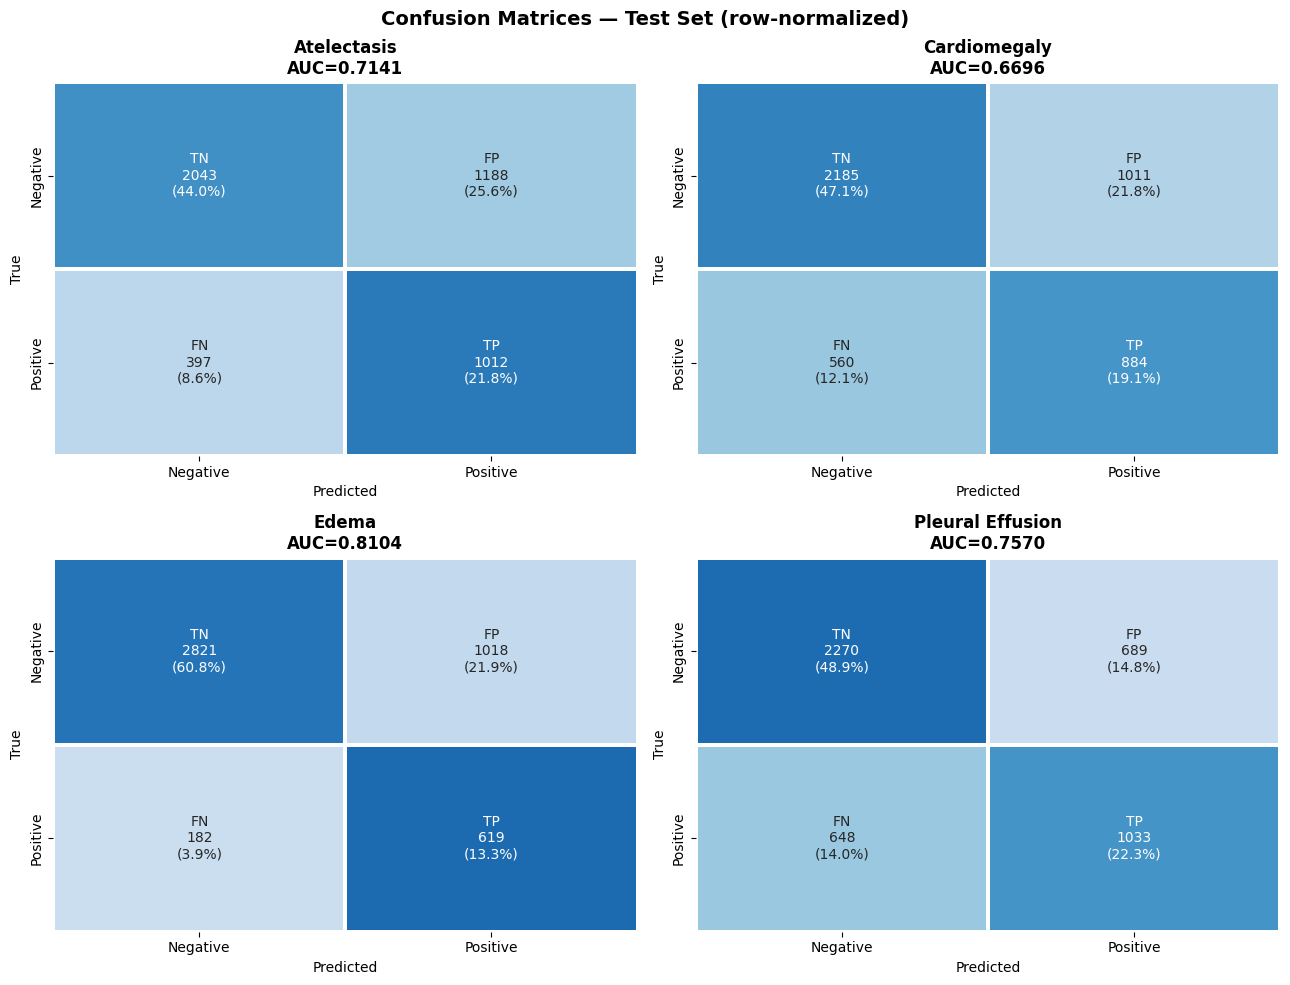

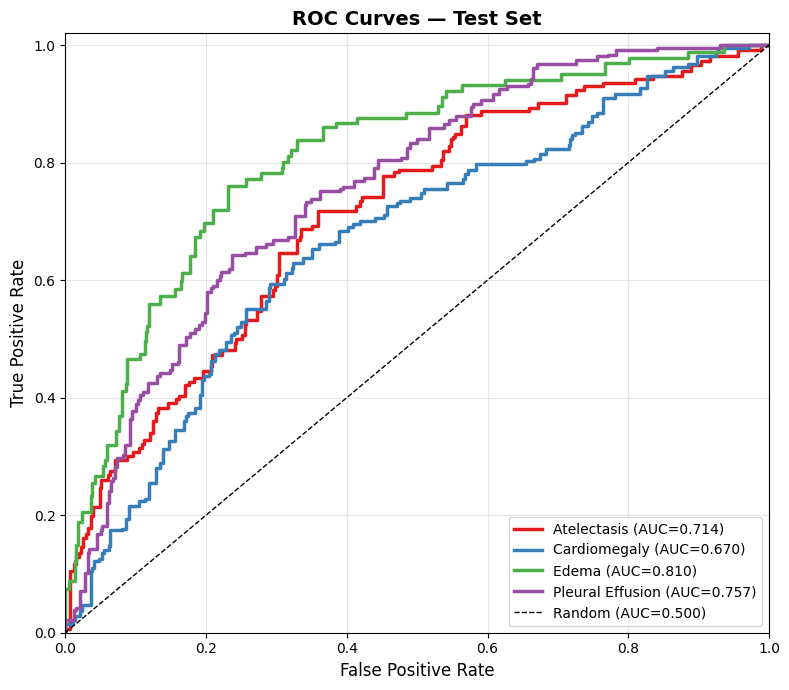

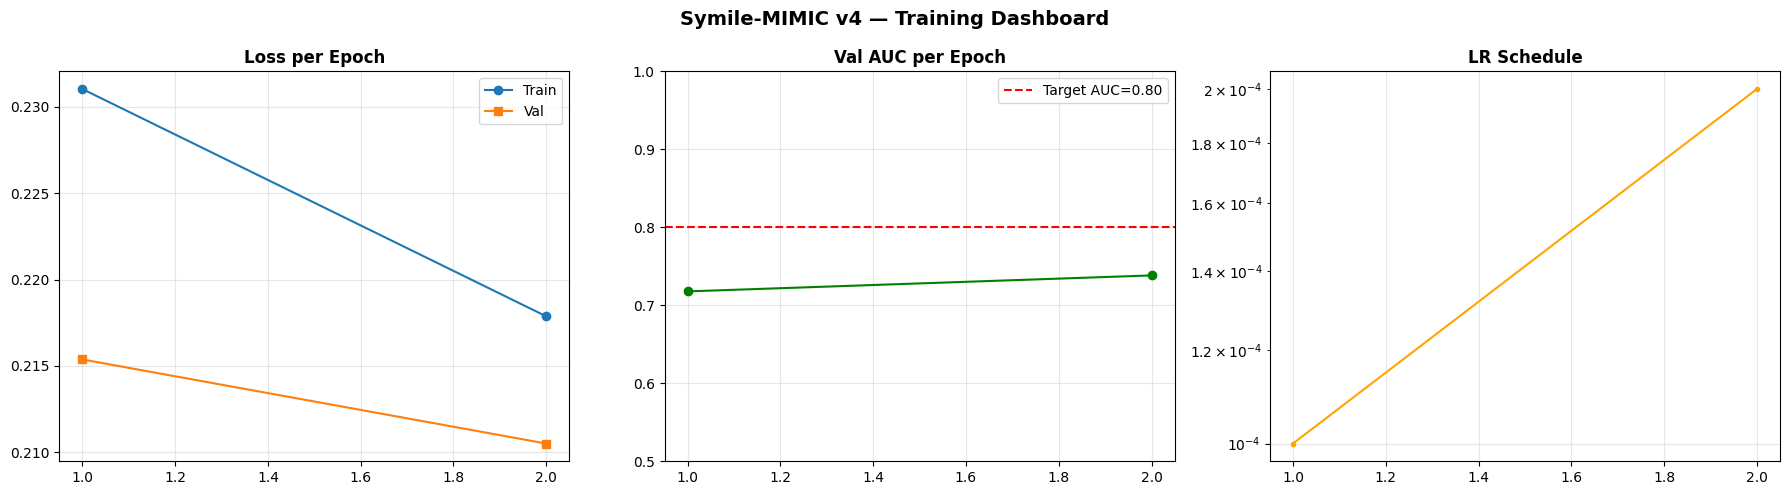


✅ All plots saved to Google Drive.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Cargar el mejor modelo y evaluar en TEST SET
# ─────────────────────────────────────────────────────────────────────────────
print('📂 Loading best checkpoint...')
ckpt = torch.load(CKPT_BEST, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'   Epoch {ckpt["epoch"]}  |  Val AUC: {ckpt["val_auc"]:.4f}')
history = ckpt.get('history', history)

@torch.no_grad()
def collect_all(model, loader, criterion, device):
    model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    for batch in loader:
        cxr   = batch['cxr'].to(device)
        ecg   = batch['ecg'].to(device)
        labs  = batch['labs'].to(device)
        label = batch['label'].to(device)
        logits = model(cxr, ecg, labs)
        total_loss += criterion(logits, label).item()
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(label.cpu().numpy())
    probs  = np.vstack(all_probs)
    labels = np.vstack(all_labels)
    preds  = (probs >= THRESHOLD).astype(int)
    return probs, preds, labels, total_loss / len(loader)

probs_t, preds_t, labels_t, test_loss = collect_all(model, test_loader, criterion, DEVICE)


# ── Tabla de métricas ─────────────────────────────────────────────────────────
print('\n' + '=' * 82)
print('                 EVALUATION METRICS DASHBOARD — TEST SET')
print('=' * 82)
print(f'  Threshold : {THRESHOLD}   |   Test Loss: {test_loss:.4f}')
print()

prec_arr, rec_arr, f1_arr, sup_arr = precision_recall_fscore_support(
    labels_t, preds_t, average=None, zero_division=0
)

hdr = f"  {'Disease':22s} | {'AUC':>7} | {'Acc':>6} | {'Prec':>6} | {'Rec':>6} | {'F1/Dice':>7} | {'IoU/Jac':>7} | N+"
print(hdr)
print('  ' + '─' * (len(hdr)-2))

auc_l, acc_l, f1_l, iou_l = [], [], [], []
for i, lbl in enumerate(TARGET_LABELS):
    try:
        auc = roc_auc_score(labels_t[:, i], probs_t[:, i])
    except ValueError:
        auc = float('nan')
    acc = accuracy_score(labels_t[:, i], preds_t[:, i])
    iou = jaccard_score(labels_t[:, i], preds_t[:, i], zero_division=0)
    auc_l.append(auc); acc_l.append(acc); iou_l.append(iou)
    icon = '🟢' if auc >= 0.78 else ('🟡' if auc >= 0.70 else '🔴')
    print(f"  {icon} {lbl:20s} | {auc:7.4f} | {acc:6.4f} | {prec_arr[i]:6.4f} | {rec_arr[i]:6.4f} | {f1_arr[i]:7.4f} | {iou:7.4f} | {sup_arr[i]}")

pm, rm, f1m, _ = precision_recall_fscore_support(labels_t, preds_t, average='macro', zero_division=0)
print('  ' + '─' * (len(hdr)-2))
print(f"  {'MACRO AVG':22s} | {np.nanmean(auc_l):7.4f} | {np.mean(acc_l):6.4f} | {pm:6.4f} | {rm:6.4f} | {f1m:7.4f} | {np.nanmean(iou_l):7.4f} |")
print('=' * 82)


# ── Figura 1: Confusion matrices ─────────────────────────────────────────────
mcm = multilabel_confusion_matrix(labels_t, preds_t)
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for i, (ax, lbl) in enumerate(zip(axes.flatten(), TARGET_LABELS)):
    tn, fp, fn, tp = mcm[i][0,0], mcm[i][0,1], mcm[i][1,0], mcm[i][1,1]
    tot = tn+fp+fn+tp
    cm_norm = mcm[i].astype(float) / mcm[i].sum(axis=1, keepdims=True).clip(min=1)
    ann = np.array([[f'TN\n{tn}\n({100*tn/tot:.1f}%)', f'FP\n{fp}\n({100*fp/tot:.1f}%)'],
                    [f'FN\n{fn}\n({100*fn/tot:.1f}%)', f'TP\n{tp}\n({100*tp/tot:.1f}%)']])
    sns.heatmap(cm_norm, ax=ax, annot=ann, fmt='', cmap='Blues',
                xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'],
                linewidths=1.5, linecolor='white', vmin=0, vmax=1, cbar=False)
    auc_val = auc_l[i]
    ax.set_title(f'{lbl}\nAUC={auc_val:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10); ax.set_ylabel('True', fontsize=10)

fig.suptitle('Confusion Matrices — Test Set (row-normalized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'v4_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()


# ── Figura 2: ROC curves ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3']
for i, (lbl, col) in enumerate(zip(TARGET_LABELS, colors)):
    try:
        fpr, tpr, _ = roc_curve(labels_t[:, i], probs_t[:, i])
        auc = roc_auc_score(labels_t[:, i], probs_t[:, i])
        ax.plot(fpr, tpr, color=col, lw=2.5, label=f'{lbl} (AUC={auc:.3f})')
    except ValueError:
        pass
ax.plot([0,1],[0,1],'k--',lw=1,label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate',fontsize=12); ax.set_ylabel('True Positive Rate',fontsize=12)
ax.set_title('ROC Curves — Test Set',fontsize=14,fontweight='bold')
ax.legend(loc='lower right',fontsize=10); ax.grid(True,alpha=0.3)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR,'v4_roc_curves.png'),dpi=150,bbox_inches='tight')
plt.show()


# ── Figura 3: Training history ────────────────────────────────────────────────
ep_r = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(ep_r, history['train_loss'], label='Train', marker='o')
axes[0].plot(ep_r, history['val_loss'],   label='Val',   marker='s')
axes[0].set_title('Loss per Epoch',fontweight='bold'); axes[0].legend(); axes[0].grid(True,alpha=0.3)
axes[1].plot(ep_r, history['val_auc'], color='green', marker='o')
axes[1].axhline(y=0.80, color='red', ls='--', label='Target AUC=0.80')
axes[1].set_title('Val AUC per Epoch',fontweight='bold'); axes[1].legend(); axes[1].grid(True,alpha=0.3)
axes[1].set_ylim([0.5,1.0])
if history.get('lr'):
    axes[2].plot(ep_r, history['lr'], color='orange', marker='.')
    axes[2].set_yscale('log'); axes[2].set_title('LR Schedule',fontweight='bold'); axes[2].grid(True,alpha=0.3)
plt.suptitle('Symile-MIMIC v4 — Training Dashboard',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR,'v4_training_history.png'),dpi=150,bbox_inches='tight')
plt.show()
print('\n✅ All plots saved to Google Drive.')

## CELDA 9 — Explicabilidad: GradCAM++ (CXR) + Saliency (ECG) + Grad×Input (Labs)

Paciente seleccionado: índice interno 4 (hadm_id: 23484796) del Test Set

  EXPLAINABILITY REPORT — Patient 4 (Test Set)
  GradCAM target class: Pleural Effusion

  Disease                |  True |  Pred |   Prob
  ---------------------------------------------
  ✅ Atelectasis          |     0 |     0 |  0.314
  ✅ Cardiomegaly         |     0 |     0 |  0.335
  ✅ Edema                |     0 |     0 |  0.254
  ❌ Pleural Effusion     |     1 |     0 |  0.370
  Target layer para GradCAM: Sequential
  ✅ GradCAM++ calculado correctamente.
  ✅ ECG Saliency calculado. Lead más relevante: V5
  ✅ Labs Gradient×Input calculado. Top lab: MIMIC itemid 50885


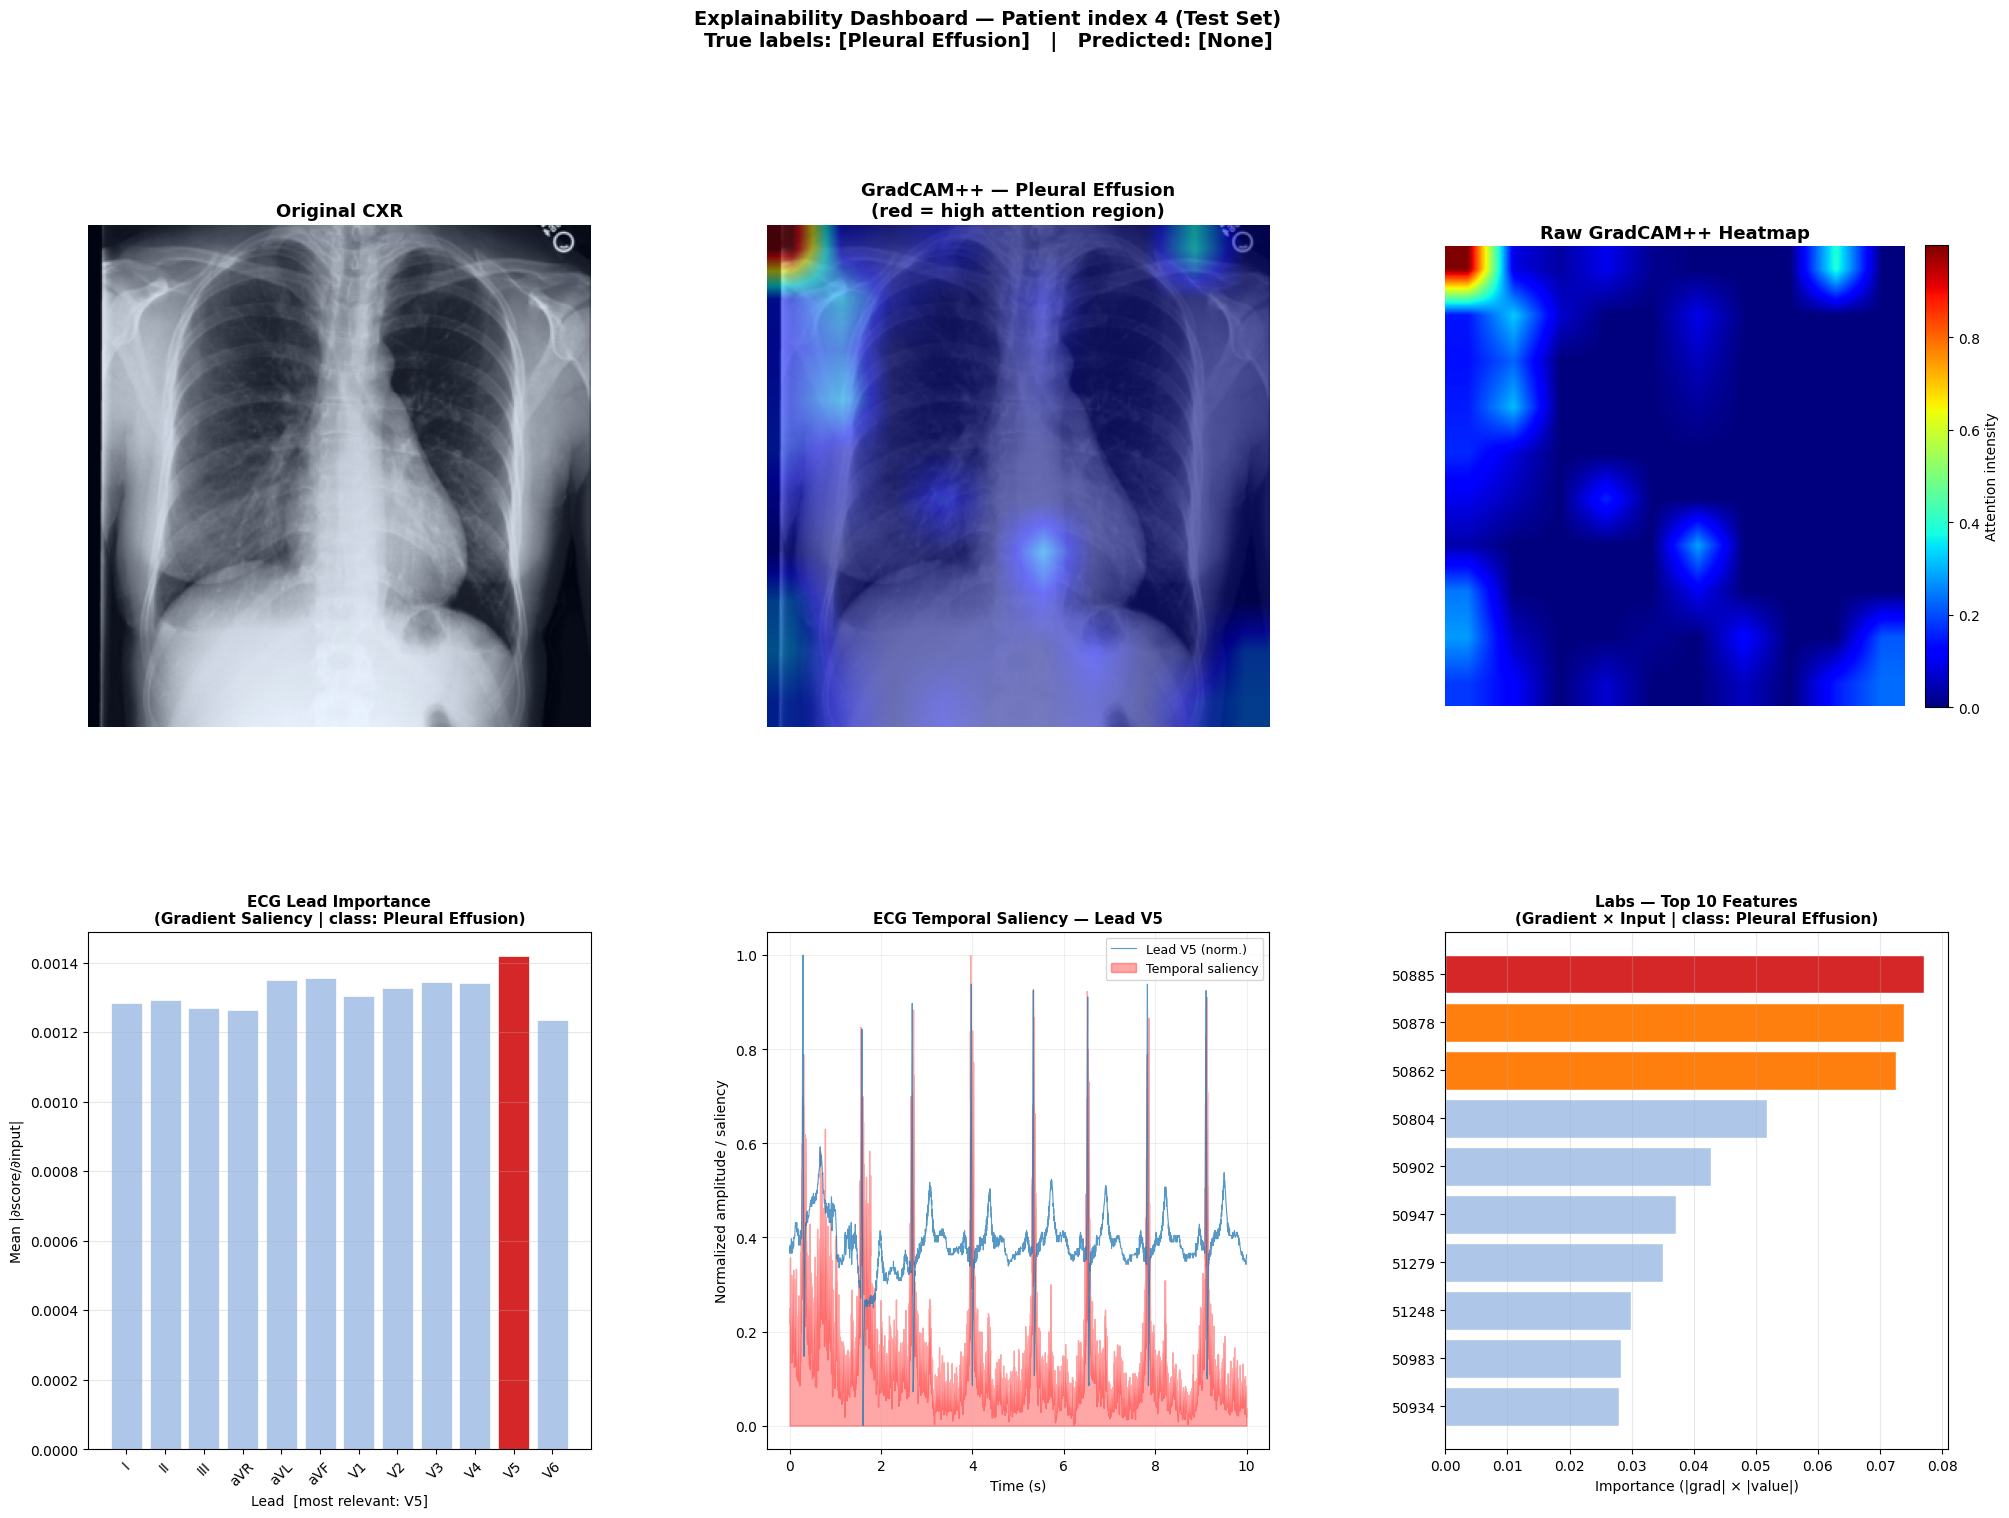


✅ Explainability dashboard saved → /content/drive/MyDrive/Proyecto_IA/v4_explainability_patient_4.png

📋 Summary:
   ECG lead más relevante : V5
   Lab más relevante      : MIMIC itemid 50885
   GradCAM target class   : Pleural Effusion  (prob=0.370)


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# EXPLICABILIDAD COMPLETA — Paciente aleatorio del Test Set
#
# Nota sobre GradCAM y EfficientNet con timm:
#   En timm, EfficientNet con features_only=True expone los bloques
#   como una lista en model.cxr_tower.backbone.
#   La target_layer para GradCAM es el último bloque convolucional
#   del backbone, accesible como backbone[-1] (último stage).
#   Se usa el wrapper CXROnlyWrapper para aislar la tower CXR.
# ─────────────────────────────────────────────────────────────────────────────

# ── Wrapper del modelo para GradCAM++ ────────────────────────────────────────
class CXROnlyWrapper(nn.Module):
    """
    Fija ECG y Labs como constantes y expone el modelo como f(cxr) → logits.
    Necesario porque GradCAM requiere un modelo con una sola entrada de imagen.
    Los tensores fijos se registran como buffers (no como parámetros)
    para que GradCAM no los incluya en el grafo de gradientes.
    """
    def __init__(self, full_model, fixed_ecg, fixed_labs):
        super().__init__()
        self.full_model = full_model
        self.register_buffer('fixed_ecg',  fixed_ecg)
        self.register_buffer('fixed_labs', fixed_labs)

    def forward(self, cxr):
        return self.full_model(cxr, self.fixed_ecg, self.fixed_labs)


# ── Seleccionar paciente por hadm_id ─────────────────────────────────────────
# Coloca aquí el hadm_id exacto que quieres analizar (ejemplo: 20175828)
TARGET_HADM_ID = 23484796

# Buscar el índice de este paciente en el dataset válido
patient_idx = None
for i, ti in enumerate(test_dataset.valid_indices):
    hid = test_dataset.hadm_ids[ti]
    # Asegurarnos de extraer el número limpio, ya sea que venga como numpy o int
    hid_val = hid.item() if hasattr(hid, 'item') else hid
    if int(hid_val) == TARGET_HADM_ID:
        patient_idx = i
        break

if patient_idx is None:
    raise ValueError(f"⚠️ [ERROR] El hadm_id {TARGET_HADM_ID} no existe en las muestras válidas del Test Set. Verifica el número.")

sample = test_dataset[patient_idx]

print(f'Paciente seleccionado: índice interno {patient_idx} (hadm_id: {TARGET_HADM_ID}) del Test Set')


# ── Predicción del modelo ─────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    logits_p = model(
        sample['cxr'].unsqueeze(0).to(DEVICE),
        sample['ecg'].unsqueeze(0).to(DEVICE),
        sample['labs'].unsqueeze(0).to(DEVICE)
    )
probs_p = torch.sigmoid(logits_p).squeeze().cpu().numpy()
preds_p = (probs_p >= THRESHOLD).astype(int)
true_p  = sample['label'].numpy().astype(int)

target_class_idx  = int(np.argmax(probs_p))   # clase con mayor probabilidad
target_class_name = TARGET_LABELS[target_class_idx]

print('\n' + '=' * 60)
print(f'  EXPLAINABILITY REPORT — Patient {patient_idx} (Test Set)')
print('=' * 60)
print(f'  GradCAM target class: {target_class_name}\n')
print(f"  {'Disease':22s} | {'True':>5} | {'Pred':>5} | {'Prob':>6}")
print('  ' + '-' * 45)
for i, lbl in enumerate(TARGET_LABELS):
    match = '✅' if true_p[i] == preds_p[i] else '❌'
    print(f"  {match} {lbl:20s} | {true_p[i]:>5} | {preds_p[i]:>5} | {probs_p[i]:>6.3f}")
print('=' * 60)


# ─────────────────────────────────────────────────────────────────────────────
# GRAD-CAM++ sobre la torre CXR
#
# Target layer: en EfficientNet-B3 con timm features_only=True,
# self.backbone es un timm FeatureListNet. Los bloques convolucionales
# se acceden como self.backbone.blocks[-1] (último stage del backbone).
# ─────────────────────────────────────────────────────────────────────────────

fixed_ecg_buf  = sample['ecg'].unsqueeze(0).to(DEVICE)
fixed_labs_buf = sample['labs'].unsqueeze(0).to(DEVICE)

cxr_wrapper = CXROnlyWrapper(model, fixed_ecg_buf, fixed_labs_buf)
cxr_wrapper = cxr_wrapper.to(DEVICE)
cxr_wrapper.eval()

# Target layer: último bloque de bloques del EfficientNet-B3
# timm FeatureListNet expone los stages como atributos del backbone;
# accedemos al último bloque convolucional del último stage.
try:
    # Intentar acceso directo al último bloque de EfficientNet
    target_layer_for_cam = [cxr_wrapper.full_model.cxr_tower.backbone.blocks[-1]]
except AttributeError:
    # Fallback: recorrer módulos y tomar la última Conv2d del backbone
    conv_layers = [m for m in cxr_wrapper.full_model.cxr_tower.backbone.modules()
                   if isinstance(m, nn.Conv2d)]
    target_layer_for_cam = [conv_layers[-1]]
    print('  ⚠️  Usando fallback: última Conv2d del backbone')

print(f'  Target layer para GradCAM: {type(target_layer_for_cam[0]).__name__}')

cxr_input = sample['cxr'].unsqueeze(0).to(DEVICE)   # (1, 3, 320, 320)

# GradCAMPlusPlus — API pytorch-grad-cam v1.5+
# use_cuda=True pasa el cómputo de gradientes a GPU
cam_algo = GradCAMPlusPlus(
    model=cxr_wrapper,
    target_layers=target_layer_for_cam
)

# targets: lista de ClassifierOutputTarget, uno por imagen del batch
cam_targets   = [ClassifierOutputTarget(target_class_idx)]
grayscale_cam = cam_algo(input_tensor=cxr_input, targets=cam_targets)  # (1, H, W)
grayscale_cam = grayscale_cam[0]   # (H, W)  — primera (y única) imagen del batch

# Preparar imagen CXR en RGB [0,1] para la superposición# Preparar imagen CXR en RGB [0,1] para la superposición
cxr_np = sample['cxr'].permute(1, 2, 0).numpy()  # (320, 320, 3)

# [CORRECCIÓN] Min-Max Scaling robusto para desnormalizar la imagen médica
cxr_min = cxr_np.min()
cxr_max = cxr_np.max()
cxr_np = (cxr_np - cxr_min) / (cxr_max - cxr_min + 1e-8) # El 1e-8 evita división por cero
cxr_np = cxr_np.astype(np.float32)

# show_cam_on_image requiere imagen [0,1] float32 y heatmap [0,1] float32
cam_overlay = show_cam_on_image(cxr_np, grayscale_cam, use_rgb=True)

print('  ✅ GradCAM++ calculado correctamente.')


# ─────────────────────────────────────────────────────────────────────────────
# GRADIENT SALIENCY sobre ECG
# Calcula |∂(score clase) / ∂(input ECG)| para identificar
# las derivaciones y los instantes temporales más relevantes.
# ─────────────────────────────────────────────────────────────────────────────

model.eval()
ec_input = sample['ecg'].unsqueeze(0).clone().to(DEVICE).requires_grad_(True)

# Forward aislado por la torre ECG para gradientes más limpios
ecg_for_grad = ec_input.squeeze(1).permute(0, 2, 1)    # (1, 12, 5000)
ecg_feat     = model.ecg_tower.encoder(ecg_for_grad)     # (1, 128, ~25)
ecg_gap      = model.ecg_tower.gap(ecg_feat)             # (1, 128, 1)
ecg_emb      = model.ecg_tower.head(ecg_gap)             # (1, 128)

# Score = suma del embedding (proxy de activación de la clase objetivo)
# Se usa el índice de la clase proyectado al rango del embedding
score_ecg = ecg_emb[0, target_class_idx % ecg_emb.shape[1]]
score_ecg.backward()

ecg_saliency = ec_input.grad.abs().squeeze().cpu().numpy()   # (5000, 12)
lead_importance = ecg_saliency.mean(axis=0)    # (12,) importancia por derivación
time_saliency   = ecg_saliency.mean(axis=1)    # (5000,) importancia temporal

top_lead_idx  = int(np.argmax(lead_importance))
top_lead_name = LEAD_NAMES[top_lead_idx]
ecg_raw_np    = sample['ecg'].squeeze(0).numpy()   # (5000, 12)

print(f'  ✅ ECG Saliency calculado. Lead más relevante: {top_lead_name}')


# ─────────────────────────────────────────────────────────────────────────────
# GRADIENT × INPUT sobre Labs
# ─────────────────────────────────────────────────────────────────────────────

labs_input = sample['labs'].unsqueeze(0).clone().to(DEVICE).requires_grad_(True)

logits_labs = model(
    sample['cxr'].unsqueeze(0).to(DEVICE),
    sample['ecg'].unsqueeze(0).to(DEVICE),
    labs_input
)
logits_labs[0, target_class_idx].backward()

labs_grad  = labs_input.grad.abs().squeeze().cpu().numpy()    # (50,)
labs_vals  = labs_input.detach().squeeze().cpu().numpy()      # (50,)
labs_imp   = labs_grad * np.abs(labs_vals)                    # Gradient × Input

top10_idx   = np.argsort(labs_imp)[::-1][:10]
top10_names = [PERCENTILE_IDS[i] for i in top10_idx]
top10_vals  = labs_imp[top10_idx]

print(f'  ✅ Labs Gradient×Input calculado. Top lab: MIMIC itemid {top10_names[0]}')


# ─────────────────────────────────────────────────────────────────────────────
# DASHBOARD DE EXPLICABILIDAD — 6 paneles
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(24, 16))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

# Panel 1: CXR original
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(cxr_np)
ax1.set_title('Original CXR', fontsize=13, fontweight='bold')
ax1.axis('off')

# Panel 2: GradCAM++ superpuesto
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(cam_overlay)
ax2.set_title(f'GradCAM++ — {target_class_name}\n(red = high attention region)',
              fontsize=13, fontweight='bold')
ax2.axis('off')

# Panel 3: Heatmap raw
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(grayscale_cam, cmap='jet')
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04, label='Attention intensity')
ax3.set_title('Raw GradCAM++ Heatmap', fontsize=13, fontweight='bold')
ax3.axis('off')

# Panel 4: ECG lead importance (barras)
ax4 = fig.add_subplot(gs[1, 0])
bar_colors = ['#d62728' if j == top_lead_idx else '#aec7e8' for j in range(12)]
ax4.bar(LEAD_NAMES, lead_importance, color=bar_colors, edgecolor='white', linewidth=0.5)
ax4.set_title(f'ECG Lead Importance\n(Gradient Saliency | class: {target_class_name})',
              fontsize=11, fontweight='bold')
ax4.set_xlabel(f'Lead  [most relevant: {top_lead_name}]', fontsize=10)
ax4.set_ylabel('Mean |∂score/∂input|', fontsize=10)
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)

# Panel 5: ECG señal + saliency temporal
ax5 = fig.add_subplot(gs[1, 1])
t_sec = np.arange(5000) / 500.0   # eje temporal en segundos (500 Hz)
sig   = ecg_raw_np[:, top_lead_idx]
sig_n = (sig - sig.min()) / max(np.ptp(sig), 1e-8)    # normalizar a [0,1]
sal_n = (time_saliency - time_saliency.min()) / max(np.ptp(time_saliency), 1e-8)
ax5.plot(t_sec, sig_n, color='#1f77b4', lw=0.8, alpha=0.75, label=f'Lead {top_lead_name} (norm.)')
ax5.fill_between(t_sec, 0, sal_n, color='red', alpha=0.35, label='Temporal saliency')
ax5.set_title(f'ECG Temporal Saliency — Lead {top_lead_name}', fontsize=11, fontweight='bold')
ax5.set_xlabel('Time (s)', fontsize=10)
ax5.set_ylabel('Normalized amplitude / saliency', fontsize=10)
ax5.legend(fontsize=9, loc='upper right')
ax5.grid(True, alpha=0.2)

# Panel 6: Labs Top-10
ax6 = fig.add_subplot(gs[1, 2])
bar_c = ['#d62728','#ff7f0e','#ff7f0e'] + ['#aec7e8'] * 7
ax6.barh(top10_names[::-1], top10_vals[::-1], color=bar_c[::-1], edgecolor='white')
ax6.set_title(f'Labs — Top 10 Features\n(Gradient × Input | class: {target_class_name})',
              fontsize=11, fontweight='bold')
ax6.set_xlabel('Importance (|grad| × |value|)', fontsize=10)
ax6.grid(axis='x', alpha=0.3)

# Título general con predicción vs. real
true_str = ', '.join([TARGET_LABELS[i] for i in range(4) if true_p[i]==1]) or 'None'
pred_str = ', '.join([TARGET_LABELS[i] for i in range(4) if preds_p[i]==1]) or 'None'
fig.suptitle(
    f'Explainability Dashboard — Patient index {patient_idx} (Test Set)\n'
    f'True labels: [{true_str}]   |   Predicted: [{pred_str}]',
    fontsize=14, fontweight='bold', y=1.01
)

out_path = os.path.join(PROJECT_DIR, f'v4_explainability_patient_{patient_idx}.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ Explainability dashboard saved → {out_path}')
print(f'\n📋 Summary:')
print(f'   ECG lead más relevante : {top_lead_name}')
print(f'   Lab más relevante      : MIMIC itemid {top10_names[0]}')
print(f'   GradCAM target class   : {target_class_name}  (prob={probs_p[target_class_idx]:.3f})')